In [1]:
import os, pickle, tempfile
import pandas as pd

In [2]:
import sys

sys.path.append("../../training_data")

In [3]:
from utils.utils import Cif, CifFileWriter
from utils.pocket_utils import Pocket

# Data

In [4]:
extra_set_path = "../../training_data/7.Extra_set"

In [5]:
with open(f"{extra_set_path}/features.pkl", "rb") as f:
    news = pickle.load(f)

len(news), news

(9,
 {'7gqu':     Residues                                                          \
           pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0       7gqu               1             A           12            A   
  1       7gqu               1             A           13            A   
  2       7gqu               1             A           14            A   
  3       7gqu               1             A           15            A   
  4       7gqu               1             A           16            A   
  ..       ...             ...           ...          ...          ...   
  414     7gqu               1             A          426            A   
  415     7gqu               1             A          427            A   
  416     7gqu               1             A          428            A   
  417     7gqu               1             A          429            A   
  418     7gqu               1             A          430            A   
  
                       

In [6]:
with open(f"{extra_set_path}/news_sites.pkl", "rb") as f:
    news_sites = {k: v for k,v in pickle.load(f).items() if k in news}

len(news_sites), news_sites

(9,
 {'7gqu': [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
    3420           X1L             D               4            .   
    
         pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
    3420                 ?        1002          X1L            A   
    
         pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
    3420                  1             1002                       ?   
    
         pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
    3420                      ?                      ?                      ?  ,
    'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    0            VAL             A               1           55                 ?   
    1            MET             A               1           56                 ?   
    2            ALA             A               1           57                 ?   
    3            THR             A     

In [7]:
assert all(len(sites) == 1 for sites in news_sites.values()), "Not all apos have a single annotated site"

In [8]:
models = pd.read_pickle("models.pkl")

models

{'model5': {'results': {'7gqu': {'pocket11': {'prob': 0.0006499344599433243,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.16666666666666666,
     'pocket_in_site': 0.16666666666666666,
     'site_in_pocket': 0.06896551724137931},
    'pocket15': {'prob': 1.6904914446058683e-05,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket7': {'prob': 1.0997085553299257e-07,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket13': {'prob': 0.0004982067039236426,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket14': {'prob': 2.0316012523835525e-05,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket1': {'prob': 0.932378888130188,
     'pred': 1,
     'label': 1,
     'max_overlap': 0.89655172

In [9]:
colors = {
    "orange": "#D55E00".lower(),
    "green": "#009E73".lower(),
    "blue": "#0072B2".lower(),
    "yellow": "#F0E442".lower()
}

# Labelling

In [10]:
# Percentage of residues of "one" in "other"
get_overlap = lambda one, other: (
    len( one.merge(other) ) / len(one)
)

def get_label(overlaps, site_in_pocket=None, pocket_in_site=None):
    assert not (site_in_pocket==None and pocket_in_site==None)
    
    if site_in_pocket is None:
        return int( overlaps["pocket_in_site"] >= pocket_in_site )
    if pocket_in_site is None:
        return int( overlaps["site_in_pocket"] >= site_in_pocket )
    return int( overlaps["site_in_pocket"] >= site_in_pocket or overlaps["pocket_in_site"] >= pocket_in_site )

In [11]:
get_overlaps = lambda pdb, pocketd: {
    name: get_overlap(*one_in_other) 
        for site in news_sites[pdb] 
            for name, one_in_other in (
                ("pocket_in_site", (pocketd["residues"], site["site"])),
                ("site_in_pocket", (site["site"], pocketd["residues"])),
            )
}

# get_overlaps_special = lambda pdb, pocketd: {
#     name: get_overlap(*one_in_other) 
#         for pocketres in (pocketd["residues"],)
#             for sited in news_sites[pdb]
#                 for site in (sited["site"].query(f"auth_asym_id == '{pocketres.auth_asym_id.unique().item()}'"),)
#                     for name, one_in_other in (
#                         ("pocket_in_site", (pocketres, site)),
#                         ("site_in_pocket", (site, pocketres)),
#                     )
# }
def get_overlaps_special(a, b):
    raise Exception("This function should not be called")

In [12]:
def label_results(resultsd, site_in_pocket=0.65, pocket_in_site=None, prob_key=None, topx=False, special_8aq6_sc=False):
    df = pd.DataFrame((
        {
            "pdb": pdb,
            "pocket": pocket,
            **{"prob": pocketd[prob_key] for prob_key in (prob_key,) if prob_key is not None},
            "pred": pocketd["pred"],
            "label": get_label(overlaps, site_in_pocket, pocket_in_site),
            "max_overlap": max(overlaps.values()),
            **overlaps,
        }
        for pdb, pockets in resultsd.items()
            if pdb != "9dnm"
        for pocket, pocketd in pockets.items()
        for overlaps in ((
            get_overlaps_special(pdb, pocketd)
            if special_8aq6_sc and pdb == "8aq6"
            else get_overlaps(pdb, pocketd)
        ),)
    ))
    
    if prob_key is not None and topx:
        df["pred"] = (
            # Start from a Series where each value/row (sample/pocket) is the total number of pos. labels on its PDB
            df.groupby("pdb")["label"].transform("sum")
            # Then subtract this "total num. of pos. in a PDB" by the rank of each pocket in a PDB, sorted by the probability
            .sub(df.groupby("pdb")["prob"].rank(method="first", ascending=False))
            # If the subtraction is positive or 0 it means that the pocket is in the topX and will be assigned 1
            >= 0
        ).astype(int)
        # If a PDB has no + labelled pocket, assign the highest prob. as positive
        for pdb, group in df.groupby("pdb"):
            if group["pred"].sum() == 0:
                df.loc[ group["prob"].idxmax(), "pred" ] = 1
    
    return df.sort_values("max_overlap", ascending=False)

In [13]:
for model, modeld in models.items():
    if model not in ["model5", "allositepro", "passer_ensemble"]: continue
    if model != "model5":
        models[model]["labelled"] = label_results(
            modeld["results"], 
            **modeld["labelling"], 
            prob_key=modeld["prob_key"],
            topx=True
        )
    else:
        # models[model]["labelled"] = label_our_results(
        #     modeld["results"], 
        #     # **modeld["labelling"]
        # )
        df = pd.DataFrame((
            {
                "pdb": pdb,
                "pocket": pocket,
                **pocketd
            }
            for pdb, pockets in modeld["results"].items()
                if pdb != "9dnm"
            for pocket, pocketd in pockets.items()
        ))
        
        df["pred"] = (
            # Start from a Series where each value/row (sample/pocket) is the total number of pos. labels on its PDB
            df.groupby("pdb")["label"].transform("sum")
            # Then subtract this "total num. of pos. in a PDB" by the rank of each pocket in a PDB, sorted by the probability
            .sub(df.groupby("pdb")["prob"].rank(method="first", ascending=False))
            # If the subtraction is positive or 0 it means that the pocket is in the topX and will be assigned 1
            >= 0
        ).astype(int)
        # If a PDB has no + labelled pocket, assign the highest prob. as positive
        for pdb, group in df.groupby("pdb"):
            if group["pred"].sum() == 0:
                df.loc[ group["prob"].idxmax(), "pred" ] = 1

        models[model]["labelled"] = df

In [14]:
models["model5"]["labelled"]

,pdb,pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket
0,7gqu,pocket11,6.499345e-04,0,0,0.166667,0.166667,0.068966
1,7gqu,pocket15,1.690491e-05,0,0,0.000000,0.000000,0.000000
2,7gqu,pocket7,1.099709e-07,0,0,0.000000,0.000000,0.000000
3,7gqu,pocket13,4.982067e-04,0,0,0.000000,0.000000,0.000000
4,7gqu,pocket14,2.031601e-05,0,0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
225,8v81,pocket21,9.221375e-04,0,0,0.000000,0.000000,0.000000
226,8v81,pocket33,2.176126e-06,0,0,0.000000,0.000000,0.000000
227,8v81,pocket36,1.134161e-01,0,0,0.000000,0.000000,0.000000
228,8v81,pocket41,7.143162e-07,0,0,0.000000,0.000000,0.000000


# Scatters

## Ortho sites

In [15]:
import pymol2

In [16]:
ortho_sitesf = f"ortho_sites.pkl"

if os.path.isfile(ortho_sitesf):
    ortho_sites = pd.read_pickle(ortho_sitesf)
else:
    ortho_sites = {}

In [17]:
def get_orthosite(ciff, pdb, chain):
    cif = Cif(pdb, ciff)
    
    with pymol2.PyMOL() as pymol:
        pymol.cmd.feedback(
            "disable", "executive", "details"
        )  # to silence "ExecutiveLoad-Detail: Detected mmCIF"
        pymol.cmd.load(ciff, "prot")
    
        site_atoms = pymol.cmd.get_model(f"(br. all within 6 of segi {'+'.join(chain)}) and polymer.protein")
    
        # Process the atom selection to obtain residue identifiers
        site_list = set(
            tuple(
                (
                    a.segi, a.chain, a.resn,
                    a.resi_number, a.ins_code or '?' # pdbx_PDB_ins_code or "?" if none
                ) 
                for a in site_atoms.atom
            )
        )
    
        if len(site_list) == 0:
            raise EmptySite("Site selection doesn't have any residues")
    
        # Transform the PyMOL-derived residue identifiers into a standard table of residues that can be used to retrieve the rows/residues from the parent structure's .residues table
        return cif.residues.merge(
            pd.DataFrame(
                site_list,
                columns=[
                    "label_asym_id", "auth_asym_id", "auth_comp_id",
                    "auth_seq_id", "pdbx_PDB_ins_code"
                ],
                dtype=str
            )
        )

In [18]:
if len(ortho_sites) == 0:
    for holo, (pdb, chains) in (
        ("7gqu", ("7gqu", ["C"])),
        ("8v81", ("8v81", [["C", "E"]])), # ["B",  "D"] is the degenerate non-catalytic site: https://journals.physiology.org/doi/full/10.1152/physrev.00007.2018
        ("8f4s", ("6wks", ["E"])),
        ("8aq6", ("7snt", ["C"])),
        # ("8uk6", ("1euy", ["C"])),
    ):
        cif = Cif(holo, f"../../training_data/7.Extra_set/cifs/{holo}.cif")
        
        if pdb == holo:
            ciff = f"../../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz"
            ortho_sites[holo] = [
                get_orthosite(ciff, pdb, chain)
                for chain in chains
            ]
            
        else:
            ciff = f"{pdb}_updated.cif"
            if not os.path.isfile(ciff):
                os.system(f"wget https://www.ebi.ac.uk/pdbe/entry-files/download/{pdb}_updated.cif -O {ciff}")
    
            for chain in chains:
                ortho_sites[holo] = [
                    site
                    for chain in chains
                    for _, site in (
                        cif.residues.merge(
                            get_orthosite(ciff, pdb, chain)[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]]
                        )
                        .groupby("label_asym_id", as_index=False, sort=False)
                    )
                ]

    # ("8uk6", ("1euy", ["C"])),
    holo = "8uk6"
    cif = Cif(holo, f"../../training_data/7.Extra_set/cifs/{holo}.cif")
    ortho_sites[holo] = [
        cif.residues.merge(
            pd.DataFrame({"label_seq_id": sorted([274, 275, 276, 277, 278, 279, 280, 286, 287, 289, 290, 294, 310, 459, 463, 476, 477, 478, 480, 481, 502, 505, 506, 507, 508, 509, 515, 517])}, dtype=str) # from manually superposing to 1euy
        ) # assumed 1 single chain in 8uk6
    ]

    pd.to_pickle(ortho_sites, ortho_sitesf)

In [19]:
ortho_sites.keys(), ortho_sites

(dict_keys(['7gqu', '8v81', '8f4s', '8aq6', '8uk6']),
 {'7gqu': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GLN             A               1           38                 ?   
   7            ALA             A               1           57                 ?   
   8            THR             A               1           58                 ?   
   9            GLY             A               1           59                 ?   
   10         

In [20]:
len(ortho_sites["8v81"]), ortho_sites["8v81"]

(1,
 [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            PHE             A               1          531                 ?   
  1            ILE             A               1          544                 ?   
  2            THR             A               1          545                 ?   
  3            LEU             A               1          546                 ?   
  4            SER             A               1          547                 ?   
  5            GLY             A               1          548                 ?   
  6            GLY             A               1          549                 ?   
  7            GLN             A               1          550                 ?   
  8            TYR             A               1          575                 ?   
  9            ASN             A               1          963                 ?   
  10           TYR             A               1         1217                 ?   


In [21]:
len(ortho_sites["8aq6"]), ortho_sites["8aq6"]

(2,
 [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            TYR             G               1           28                 ?   
  1            ASN             G               1           29                 ?   
  2            LEU             G               1           30                 ?   
  3            VAL             G               1           33                 ?   
  4            LEU             G               1           34                 ?   
  5            LEU             G               1           42                 ?   
  6            PHE             G               1           43                 ?   
  7            GLN             G               1           44                 ?   
  8            LEU             G               1           46                 ?   
  9            GLY             G               1           47                 ?   
  10           VAL             G               1           48                 ?   


In [22]:
ortho_sites["8uk6"]

[   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
 0            ARG             A               1          274                 ?   
 1            PHE             A               1          275                 ?   
 2            PRO             A               1          276                 ?   
 3            PRO             A               1          277                 ?   
 4            GLU             A               1          278                 ?   
 5            PRO             A               1          279                 ?   
 6            ASN             A               1          280                 ?   
 7            GLY             A               1          286                 ?   
 8            HIS             A               1          287                 ?   
 9            LYS             A               1          289                 ?   
 10           ALA             A               1          290                 ?   
 11           AS

In [23]:
ortho_labels = {}

for pdb, pdbd in models["model5"]["results"].items():
    if pdb not in ortho_sites: continue
        
    ortho_sites_pdb = ortho_sites[pdb]
    ortho_labels[pdb] = {}
    
    for pocket, pocketd in pdbd.items():
        pocketres = Pocket(f"../../training_data/7.Extra_set/pockets/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif").residues

        overlaps = max(
            (
                {
                    name: get_overlap(*one_in_other)
                        for name, one_in_other in (
                            ("pocket_in_site", (pocketres, site)),
                            ("site_in_pocket", (site, pocketres)),
                        )
                }
                for site in ortho_sites_pdb
            ),
            key=lambda x: x["site_in_pocket"]
        )
        
        ortho_labels[pdb][pocket] = {
            "ortho_label": get_label(overlaps, site_in_pocket=0.65, pocket_in_site=None),
            "ortho_max_overlap": max(overlaps.values()),
            **{f"ortho_{k}": v for k, v in overlaps.items()},
            **pocketd
        }

ortho_labels.keys(), ortho_labels

(dict_keys(['7gqu', '8aq6', '8f4s', '8uk6', '8v81']),
 {'7gqu': {'pocket11': {'ortho_label': 0,
    'ortho_max_overlap': 0.0,
    'ortho_pocket_in_site': 0.0,
    'ortho_site_in_pocket': 0.0,
    'prob': 0.0006499344599433243,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.16666666666666666,
    'pocket_in_site': 0.16666666666666666,
    'site_in_pocket': 0.06896551724137931},
   'pocket15': {'ortho_label': 0,
    'ortho_max_overlap': 0.21428571428571427,
    'ortho_pocket_in_site': 0.21428571428571427,
    'ortho_site_in_pocket': 0.14285714285714285,
    'prob': 1.6904914446058683e-05,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket7': {'ortho_label': 0,
    'ortho_max_overlap': 0.0,
    'ortho_pocket_in_site': 0.0,
    'ortho_site_in_pocket': 0.0,
    'prob': 1.0997085553299257e-07,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket13': {

In [24]:
pd.DataFrame((
    {
        "pdb": pdb,
        "pocket": pocket,
        **pocketd
    }
    for pdb, pockets in ortho_labels.items()
    for pocket, pocketd in pockets.items()
)).sort_values("ortho_max_overlap", ascending=False).iloc[:40]

,pdb,pocket,ortho_label,ortho_max_overlap,ortho_pocket_in_site,ortho_site_in_pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket
5,7gqu,pocket1,1,0.952381,0.162602,0.952381,9.323789e-01,1,1,0.896552,0.211382,0.896552
99,8v81,pocket43,1,0.928571,0.247619,0.928571,4.873215e-01,0,0,0.000000,0.000000,0.000000
24,8aq6,pocket8,0,0.750000,0.750000,0.333333,1.292450e-02,0,0,0.000000,0.000000,0.000000
30,8f4s,pocket2,1,0.720000,0.666667,0.720000,8.830661e-02,0,0,0.000000,0.000000,0.000000
19,8aq6,pocket2,0,0.714286,0.714286,0.416667,1.444349e-03,0,0,0.047619,0.047619,0.034483
46,8uk6,pocket13,0,0.705882,0.705882,0.428571,1.861936e-02,0,0,0.294118,0.294118,0.238095
25,8aq6,pocket3,0,0.684211,0.684211,0.361111,3.852852e-03,0,0,0.000000,0.000000,0.000000
63,8uk6,pocket3,0,0.535714,0.441176,0.535714,9.406286e-02,0,0,0.000000,0.000000,0.000000
23,8aq6,pocket5,0,0.411765,0.411765,0.194444,2.919853e-03,0,0,0.058824,0.058824,0.034483
20,8aq6,pocket4,0,0.400000,0.400000,0.111111,6.997005e-05,0,0,0.000000,0.000000,0.000000


In [32]:
ortho_pockets = {
    "7gqu": ("pocket1",),
    "8v81": ("pocket43",), # , "pocket17"
    "8aq6": ("pocket2", "pocket3"),
    "8f4s": ("pocket2",),
    "8uk6": ("pocket3",)
}

## Plots

In [33]:
df = models["model5"]["labelled"]

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------------
# CONFIGURATION (tune these)
# ------------------------------------------------------------------

# Figure size (inches)
fig_width  = 1.75
fig_height = 2.25

boxplot_widths = 0.4

# Reference size for which base_fs_ref was chosen
ref_fig_width  = 1.5
ref_fig_height = 2.5
base_fs_ref    = 12.5   # base font size for the reference figure size

# Scale fonts with figure size (use min so fonts don't explode if aspect changes)
size_scale = min(fig_width / ref_fig_width, fig_height / ref_fig_height)
base_fs    = base_fs_ref * size_scale

# Font sizes
fs_tick_factor  = 0.8
fs_label_factor = 1
# fs_title_factor = 1.4

fs_tick  = base_fs * fs_tick_factor
fs_label = base_fs * fs_label_factor
# fs_title = base_fs * fs_title_factor

# Scatter / box / axis styling
point_size       = 30            # size of scatter points
scatter_alpha    = 0.5

# How far in y we consider "neighbors" for crowding, as fraction of y-range
density_band_frac = 0.05   # e.g. 5% of the y-range
jitter_width     = 0.2          # horizontal jitter of points

text_offset_frac = 0.05         # vertical distance between max point and its label (fraction of y-range)
text_offset_frac_x = 0.4
box_linewidth    = 0.8           # boxplot line thickness
axis_linewidth   = 0.8           # axis spine thickness

# Y-tick control
n_yticks           = 5           # maximum number of y ticks
use_custom_yticks  = False       # set to True to use custom_yticks instead of automatic
custom_yticks      = [0.0, 0.25, 0.5, 0.75, 1.0]  # example, only used if use_custom_yticks=True

# Colors
light_grey   = "0.75"            # base color for points
# label_color  = "tab:orange"      # example color if label == 1
# pred_color   = "tab:blue"        # example color if pred == 1
# both_color   = "tab:green"       # example color if label == 1 and pred == 1

def point_color(row):
    pdb = row["pdb"]
    pred = row["pred"]
    label = row["label"]
    if pdb in ortho_pockets and pdb != "7gqu":
        if row["pocket"] in ortho_pockets[row["pdb"]]:
            return colors["yellow"]
    if pred and label:
        return colors["green"]
    elif label:
        return colors["orange"]
    elif pred:
        return colors["blue"]
    else:
        return light_grey

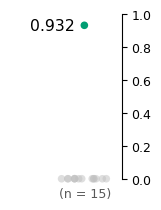

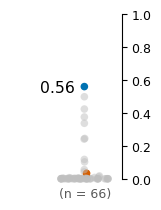

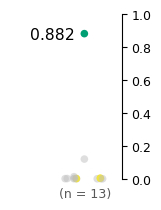

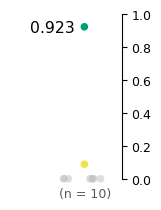

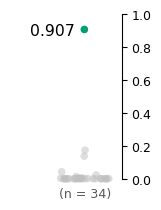

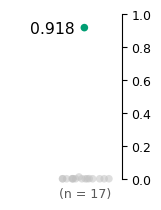

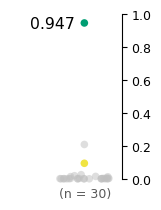

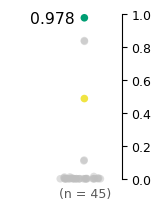

In [35]:
# Output
output_prefix = "boxplot_"       # files will be like "boxplot_7gqu.svg"

# ------------------------------------------------------------------
# Matplotlib global settings (text as text in SVG, transparent, etc.)
# ------------------------------------------------------------------

rcParams["font.size"] = base_fs
rcParams["ytick.labelsize"] = fs_tick
rcParams["svg.fonttype"] = "none"      # keep text as text, not paths -> nicer in PowerPoint
rcParams["axes.linewidth"] = axis_linewidth

# ------------------------------------------------------------------
# MAIN: loop over pdb and create one boxplot+scatter per pdb
# Assumes your dataframe is called `df` and has at least:
#   'pdb', 'prob', 'pred', 'label'
# ------------------------------------------------------------------

for pdb_id, sub in df.groupby("pdb"):
    sub = sub.copy()
    probs = sub["prob"].to_numpy()

    # Skip if no valid data
    if len(probs) == 0 or np.all(np.isnan(probs)):
        continue

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Y-limits (add some margin)
    y_min = np.nanmin(probs)
    y_max = np.nanmax(probs)
    if y_min == y_max:
        # if all equal, pad a bit
        if y_min == 0:
            y_min, y_max = -0.1, 0.1
        else:
            y_min *= 0.9
            y_max *= 1.1
    y_range = y_max - y_min
    # ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.15 * y_range)
    ax.set_ylim(0, 1)

    # Scatter with jitter
    # x_vals = 0 + (np.random.rand(len(sub)) - 0.5) * 2 * jitter_width
    sc_colors = [point_color(row) for _, row in sub.iterrows()]
    alphas = [
        scatter_alpha if c == light_grey else 1 
        for c in sc_colors
    ]

    # Beeswarm-like jitter
    counts = np.array([
        len(ind) for ind in NearestNeighbors(radius=density_band_frac*y_range)
        .fit(probs.reshape(-1,1))
        .radius_neighbors(probs.reshape(-1,1), return_distance=False)
    ])
    x_vals = (np.random.rand(len(probs))-0.5) * 2 * jitter_width * np.maximum(0, (counts-1)/(counts.max()-1+1e-12))
    # print(np.min(x_vals), np.max(x_vals))
    ax.set_xlim(-0.6, 0.3)

    ax.scatter(
        x_vals,
        probs,
        s=point_size,
        c=sc_colors,
        alpha=alphas,
        edgecolors="none",
        zorder=1,
        clip_on=False
    )

    # Annotate max point
    idx_max = int(np.nanargmax(probs))
    x_max = x_vals[idx_max]
    y_max_point = probs[idx_max]

    # Format prob with up to 3 decimals, no trailing zeros
    text_val = f"{y_max_point:.3f}".rstrip("0").rstrip(".")

    ax.text(
        x_max - jitter_width * text_offset_frac_x,
        y_max_point - text_offset_frac,
        text_val,
        ha="right",
        va="bottom",
        fontsize=fs_label,
    )

    # # Boxplot: thin black lines, no fill
    # bp = ax.boxplot(
    #     probs,
    #     positions=[0],
    #     widths=boxplot_widths,
    #     vert=True,
    #     patch_artist=False,  # no box fill
    #     showfliers=False,
    #     whiskerprops=dict(color="black", linewidth=box_linewidth),
    #     capprops=dict(color="black", linewidth=box_linewidth),
    #     medianprops=dict(color="black", linewidth=box_linewidth),
    #     boxprops=dict(color="black", linewidth=box_linewidth),
    # )
    # for artist in bp['boxes'] + bp['whiskers'] + bp['caps'] + bp['medians']:
    #     artist.set_clip_on(False)

    # Remove all spines except right
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(axis_linewidth)

    # Axis formatting: vertical plot, ticks on the right only
    ax.set_xticks([])
    ax.tick_params(axis="x", which="both", length=0)

    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    if use_custom_yticks:
        ax.set_yticks(custom_yticks)
    else:
        ax.yaxis.set_major_locator(MaxNLocator(n_yticks))

    ax.tick_params(axis="y", labelsize=fs_tick)
    ax.set_ylabel("")
    # ax.set_title("")

    # Transparent background (figure + axes)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    ax.set_xlabel(f"(n = {len(sub)})", fontsize=fs_tick, color="0.35")
    ax.xaxis.set_label_coords(0.675, -0.05)
    
    plt.tight_layout()

    # Save as transparent SVG, ready for PowerPoint
    out_name = f"{output_prefix}{pdb_id}.svg"
    fig.savefig( out_name, dpi=300, transparent=True)
    # plt.close(fig)
    plt.show()
    # break

In [36]:
df.query("pdb == '8v81'").sort_values("prob", ascending=False)

,pdb,pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket
201,8v81,pocket1,9.780471e-01,1,1,0.962963,0.208000,0.962963
210,8v81,pocket17,8.395897e-01,0,0,0.000000,0.000000,0.000000
207,8v81,pocket4,8.350534e-01,0,0,0.000000,0.000000,0.000000
216,8v81,pocket43,4.873215e-01,0,0,0.000000,0.000000,0.000000
227,8v81,pocket36,1.134161e-01,0,0,0.000000,0.000000,0.000000
203,8v81,pocket44,1.090163e-01,0,0,0.000000,0.000000,0.000000
206,8v81,pocket20,1.399745e-02,0,0,0.000000,0.000000,0.000000
204,8v81,pocket2,1.088807e-02,0,0,0.000000,0.000000,0.000000
229,8v81,pocket6,1.044861e-02,0,0,0.000000,0.000000,0.000000
200,8v81,pocket26,5.784639e-03,0,0,0.000000,0.000000,0.000000


# Pocket functions

In [30]:
from biotite.structure.io.pdb import PDBFile

def get_pdb_atoms(f):
    atom_array = PDBFile.read(f).get_structure()
    return pd.DataFrame({
            "auth_asym_id": atom_array.chain_id,
            "auth_seq_id": atom_array.res_id,
            "auth_comp_id": atom_array.res_name,
            "auth_atom_id": atom_array.atom_name,
            "type_symbol": atom_array.element,
            "Cartn_x": atom_array.coord[0][:, 0],
            "Cartn_y": atom_array.coord[0][:, 1],
            "Cartn_z": atom_array.coord[0][:, 2],
            "pdbx_PDB_ins_code": (ic or '?' for ic in atom_array.ins_code)
        }, dtype=str)

In [31]:
def get_pocket(pocket_atoms, res_id, color):
    pocket_atoms["label_entity_id"] = '99'
    return {
        "pocketn": res_id,
        "atoms": pocket_atoms, 
        "representation": {
            "selection": [{'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(res_id)}], 
            'color': colors[color]
        }
    }

In [32]:
def get_our_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     Cif(pdb, f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif", name=f"{pdb}_out")
    #     .atoms
    #     .query(f"label_comp_id == 'STP' and label_seq_id == '{pocketn}'")
    # )

    return {
        "pocketsf": f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif",
        "pocketn": pocketn,
        "pocket_sel": [{"label_comp_id": 'STP', "label_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)
# {
#         "atoms": pocket_atoms, 
#         "representation": {
#             "selection": {'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(pocketn)}, 
#             'color': colors[color]
#         }
#     }

models["model5"]["pocketf"] = get_our_pocket

In [33]:
def get_allositepro_pocket(pdb, pocket, color):
    resultsf = next(f for f in os.listdir(f"AllositePro/{pdb}") if f.endswith("_download"))
    # pockets are 0-indexed but residue numbers start at 1
    # also pocket0 can be residue ID 2, so all pockets auth_seq_id will be sorted and then the relevant residue id taken with the 0-index pocket number
    pockets_atoms = (
        get_pdb_atoms(f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb")
        .query(f"auth_comp_id == 'STP'")
    )
    pocketn = sorted(pockets_atoms.auth_seq_id.unique())[ int(pocket.replace('pocket', '')) ]
    # pocket_atoms = pockets_atoms.query(f"auth_seq_id == '{pocketn}'")
    
    return {
        "pocketsf": f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["allositepro"]["pocketf"] = get_allositepro_pocket

In [34]:
from functools import partial

In [35]:
def get_passer_pocket(pdb, pocket, color, model):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     get_pdb_atoms(f"PASSer/{model}/{pdb}/{pdb}_out.pdb")
    #     .query(f"auth_comp_id == 'STP' and auth_seq_id == '{pocketn}'")
    # )
    
    return {
        "pocketsf": f"PASSer/{model}/{pdb}/{pdb}_out.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["passer_ensemble"]["pocketf"] = partial(get_passer_pocket, model="ensemble")
models["passer_automl"]["pocketf"] = partial(get_passer_pocket, model="automl")
models["passer_rank"]["pocketf"] = partial(get_passer_pocket, model="rank")

# View functions

In [36]:
import molviewspec as mvs
import json
from pathlib import Path

In [87]:
# ass_fields_list = ["_pdbx_struct_assembly", "_pdbx_struct_assembly_gen", "_pdbx_struct_oper_list"]

def view_pockets(pdb, model, pockets:list):
    cif = Cif(pdb, f"{extra_set_path}/origcifs/{pdb}_updated.cif.gz")

    # minimal_elements = lambda element="label_asym_id": site["site"][element].unique().tolist() + site["mod"][element].unique().tolist()

    site = news_sites[pdb][0]
    # atoms = cif.atoms.query(f"label_asym_id in {minimal_elements('label_asym_id')}")

    # # Fake entity data
    # entities = pd.concat((
    #     pd.DataFrame(cif.cif.data["_entity"], dtype=str),#.query(f"id in {minimal_elements('label_entity_id')}"),
    #     pd.DataFrame([{"id": "99", "type": "branched", "pdbx_description": "pockets"}]) # Fake the pockets as carbohydrates to manage their representation
    # )).fillna(".")

    

    # columns = list( set.intersection( *map(set, (pocket_atoms["atoms"].columns for pocket_atoms in pockets)) ) )
    # atoms = pd.concat((
    #     cif.atoms[columns],
    #     *(pocket_atoms["atoms"][columns] for pocket_atoms in pockets)
    # ))

    # with tempfile.NamedTemporaryFile("w+", suffix=".cif") as f:
    #     writer = CifFileWriter(f.name)
    #     writer.write({cif.entry_id.upper(): {
    #         "_entity": entities.to_dict(orient="list"),
    #         "_atom_site": atoms.to_dict(orient="list"),
    #         # **{k: cif.cif.data[k] for k in ass_fields_list}
    #     }})
    #     combined = Cif(pdb, filename=f.name)
    #     combined.cif.data # to cache it while 'f' exists

    
    builder = mvs.create_builder()
    structure = (
        builder.download(url=f"{pdb}.cif")
        .parse(format="mmcif")
        .model_structure()
    )
    assets = {f'{pdb}.cif': cif.cif.text.encode()}

    if custom_vizs[pdb]["camera"]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"]["camera"].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )
    if model in custom_vizs[pdb]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"][model].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )

    # Protein and site
    for auth_asym_id, siteres in site["site"].groupby("auth_asym_id"):
        protein = (
            structure
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in custom_vizs[pdb]["selections"].get(f"protein_{auth_asym_id}", [{"auth_asym_id": auth_asym_id},])
            ])
            .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})#, custom={"ignoreLight": True})
            .color(color='#DADADA')
        )

        annos = f'annos_chain_{auth_asym_id}.json'
        assets[annos] = json.dumps(
            [
                {
                    'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                    'color': 'black' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for i, r in siteres.iterrows()
            ]
        ).encode()
        protein.color_from_uri(uri=annos, format='json', schema='all_atomic')

        if model == "model5":
            for i, osite in enumerate(ortho_sites.get(pdb, [])):
                osite = osite.query(f"auth_asym_id == '{auth_asym_id}'").merge(
                    siteres,
                    how="left", indicator=True
                ).query("_merge == 'left_only'").drop(columns="_merge")
                
                if len(osite) == 0: continue
                annos = f'ortho_annos_{auth_asym_id}_{i}.json'
                assets[annos] = json.dumps(
                    [
                        {
                            'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                            'color': colors["yellow"] # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                        }
                        for i, r in osite.iterrows()
                    ]
                ).encode()
                protein.color_from_uri(uri=annos, format='json', schema='all_atomic')
            
            
    # Ligands
    if not custom_vizs[pdb]["ligands"]["none"]:
        for entity_id in entities.query("type == 'non-polymer'").id.unique():
            if entity_id not in site["mod"].label_entity_id.unique():
                (
                    structure
                    .component(selector=mvs.ComponentExpression(label_entity_id=entity_id))
                    .representation(type="ball_and_stick", custom={"molstar_representation_params": {"ignoreLight": True}})
                    .color(color="white")
                )
    if model in custom_vizs[pdb]["ligands"]:
        for lig in custom_vizs[pdb]["ligands"][model]:
            (
                structure
                .component(selector=mvs.ComponentExpression(**lig))
                .representation(
                    type="ball_and_stick", 
                    size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
                    custom={"molstar_representation_params": {"ignoreLight": True}})
                .color(
                    custom={
                        "molstar_color_theme_name": "element-symbol",
                        "molstar_color_theme_params": {
                            "carbonColor": { "name": "uniform", "params": {"value": int("#808080".replace('#', ''), 16)} }
                        }
                    }
                )
                # .opacity(opacity=0.9)
            )
    
    # Modulator
    # for entity_id in entities.query("type == 'non-polymer'").id.unique():
    for entity_id in site["mod"].label_entity_id.unique():
        (
            structure
            .component(selector=mvs.ComponentExpression(label_entity_id=entity_id))
            .representation(
                type="ball_and_stick", 
                size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
                custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(
                custom={
                    "molstar_color_theme_name": "element-symbol",
                    "molstar_color_theme_params": {
                        "carbonColor": { "name": "uniform", "params": {"value": int("#666666".replace('#', ''), 16)} }
                    }
                }
            )
            # .opacity(opacity=0.9)
        )



    # Pockets
    pockets_strs = {}
    for i, pocket in enumerate(pockets):
        pocketf = Path(pocket["pocketsf"])
        name = pocketf.name
        if name not in assets:
            pockets_strs[name] = (
                builder.download(url=name)
                .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                .model_structure()
            )
            with open(pocketf, "r") as f:
                assets[name] = f.read().encode()
        
        (
            pockets_strs[name]
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in pocket["pocket_sel"]
            ])
            .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(color=pocket["color"])
            .opacity(
                opacity=(
                    custom_vizs[pdb]["pocket_opacity"]
                    .get(model, {pocket["pocketn"]: 0.5})
                    .get(pocket["pocketn"])
                )
            )
        )
    


    # View
    return mvs.MVSX(
        data=builder.get_state(),
        assets=assets
    )
    # v = mvsx.molstar_notebook(width= 1725, height= 875)
    # return v

In [88]:
def view_top(pdb, model, top=None):
    pocketf = models[model]["pocketf"]
    prob_key = models[model]["prob_key"]
    results = models[model]["results"][pdb]
    labelled = models[model]["labelled"].query(f"pdb == '{pdb}'").sort_values("prob", ascending=False)
    pos_pockets = labelled[labelled["label"] == 1]

    if top is None:
        top = labelled["label"].sum() or 1
    top_pockets = tuple(pocket for i, pocket in tuple(labelled.iterrows())[:top])

    for pocket in top_pockets:
        print(pocket["pocket"], {k: v for k, v in results[pocket["pocket"]].items() if k != "residues"}, "label:", pocket["label"])
        
    return view_pockets(
        pdb,
        model,
        tuple(
            [
                pocketf(pdb, pocket["pocket"], "green" if pocket["label"] == 1 else "blue")
                for pocket in top_pockets
            ] + [
                pocketf(pdb, pocket["pocket"], "orange")
                for i, pocket in pos_pockets.iterrows()
                if pocket["pocket"] not in (p["pocket"] for p in top_pockets)
            ]
        )
    )

# Viz

In [104]:
custom_vizs = {
    p: {
        "camera": {"camera": False}, # set a common camera after revision; also model-specific
        "ligands": {"none": False}, # set to True after revision; also model-specific; also size_factor
        "selections": {},
        "pocket_opacity": {}
    }
    for p in news.keys()
}


custom_vizs["7yg5"].update({
        "camera": {
            "camera": """{
    position: [95.49, 187.55, 251.44],
    target: [152.01, 159.35, 167.46],
    up: [0.84, 0.14, 0.52],
}""",
            "allositepro": """{
    position: [223.05, 143.6, 75.27],
    target: [152.01, 159.35, 167.46],
    up: [0.8, 0.15, 0.59],
}""",
            "passer_ensemble": """{
    position: [223.05, 143.6, 75.27],
    target: [152.01, 159.35, 167.46],
    up: [0.8, 0.15, 0.59],
}""",
        },
        "ligands": {
            "none": True,
            "size_factor": 0.7,
            "model5": [{"auth_asym_id": "A", "auth_seq_id": 2404},]
        },
        "pocket_opacity": {
            "allositepro": {"2": 0.7}
        }
    })


custom_vizs["7gqu"].update({
        "camera": {
            "camera": """{
    position: [77.37, 31.66, 32.78],
    target: [5.74, 27.52, 18.12],
    up: [0.04, 0.89, -0.46],
}""",
        },
        "ligands": {"none": True},
        "pocket_opacity": {
            "allositepro": {"2": 0.7}
        }
    })



# custom_vizs["8aq6"].update({
#         "camera": {
#             "camera": """{
#     position: [42.49, -12.34, 85.5],
#     target: [44.34, -49.6, 65.39],
#     up: [0.88, -0.19, 0.43],
# }""",
#         },
#         "ligands": {"none": True},
#         "pocket_opacity": {
#             "allositepro": {"1": 0.8},
#             "passer_ensemble": {"3": 0.8},
#             "allo": {"P_2": 0.8}
#         }
#     })
custom_vizs["8aq6"].update({
        "camera": {
            "camera": """{
    position: [37.77, -48.63, 16.79],
    target: [44.64, -43.77, 62.23],
    up: [-0.98, 0.16, 0.13],
}""",
        },
        "ligands": {"none": True},
        "selections": {
                "protein_G": [{"auth_asym_id": "G", "beg_auth_seq_id": 2, "end_auth_seq_id": 169},],
                "protein_H": [{"auth_asym_id": "H", "beg_auth_seq_id": 2, "end_auth_seq_id": 169},]
            }
    })



custom_vizs["8f4s"].update({
        "camera": {
            "camera": """{
    position: [130.24, -13.79, 42.98],
    target: [94.2, 25.11, 24.15],
    up: [-0.39, 0.08, 0.92],
}""", # Establish the camera
        },
        "ligands": {"none": True},
        "selections": {
            "protein_A": [{"auth_asym_id": "A", "beg_auth_seq_id": 6799, "end_auth_seq_id": 7091},]
        }
    })


custom_vizs["8jp0"].update({
        "camera": {
            "camera": """{
    position: [103.33, 108.95, 69.94],
    target: [130.69, 134.14, 126.6],
    up: [-0.91, 0.09, 0.4],
}""", # Establish the camera
        },
        "ligands": {"none": True},
        "pocket_opacity": {
            "allositepro": {"2": 0.6}
        }
    })



custom_vizs["8qni"].update({
        "camera": {
            "camera": """{
    position: [31.03, 30.61, 94.01],
    target: [18.05, 10.31, 31.44],
    up: [0.18, 0.93, -0.34],
}""", # Establish the camera
        },
        "ligands": {"none": True},
        "selections": {
            "protein_A": [{"auth_asym_id": "A", "beg_auth_seq_id": 5, "end_auth_seq_id": 349},]
        }
    })


custom_vizs["8uk6"].update({
        "camera": {
            "camera": """{
    position: [111.85, 20.63, 87.19],
    target: [47.48, 25.38, 18.04],
    up: [0.43, -0.78, -0.46],
}""", # Establish the camera
        },
        "ligands": {"none": True},
    })




custom_vizs["8v81"].update({
        "camera": {
            "camera": """{
    position: [110.01, 224.39, 228.89],
    target: [150.45, 123.5, 140.12],
    up: [-0.62, 0.36, -0.69],
}""", # Establish the camera
        },
        "ligands": {
            "none": True, 
            "size_factor": 0.7,
            "passer_ensemble": [{"auth_asym_id": "A", "beg_auth_seq_id": 1501, "end_auth_seq_id": 1504},]
        },
        "pocket_opacity": {
            "allositepro": {"1": 0.7},
            # "passer_ensemble": {"49": 0.6}
        }
    })



# custom_vizs["9dnm"].update({
#         "camera": {
#             "camera": """{
#     position: [224.61, 233.28, 104.7],
#     target: [205.02, 209.34, 179.72],
#     up: [-0.7, 0.71, 0.05],
# }""", # Establish the camera
#         },
#         "ligands": {
#             "none": True, 
#             "size_factor": 0.7
#         },
#         "selections": {
#             "protein_A": [
#                 {"auth_asym_id": "A", "beg_auth_seq_id": 1, "end_auth_seq_id": 176},
#                 {"auth_asym_id": "A", "beg_auth_seq_id": 283, "end_auth_seq_id": 494},
#             ]
#         },
#         "pocket_opacity": {
#             "passer_ensemble": {"20": 0.7},
#             "allo": {"P_0": 0.5}
#         }
#     })

- Components settings: Ignore light
- Examine ligands and make selection+component or hide all
- Duplicate spacefill (modulator), add stick-and-ball and hide spacefill. Carbon color uniform: ~30,30,30
- Adjust molecular surface Probe radius and Opacity (0.4)

In [105]:
news.keys()

dict_keys(['7gqu', '7yg5', '8aq6', '8f4s', '8jp0', '8qni', '8uk6', '8v81', '9dnm'])

In [106]:
modell = ["model5", "allositepro", "passer_ensemble"]#, "allo"]

In [107]:
i = 0

In [108]:
curr_model = modell[i]; print(curr_model)
i += 1
mvsx = view_top('8qni', curr_model); mvsx.molstar_notebook(width= 1100, height= 500)

model5
pocket1 {'prob': 0.9183333516120911, 'pred': 1, 'label': 1, 'max_overlap': 0.9666666666666667, 'pocket_in_site': 0.32222222222222224, 'site_in_pocket': 0.9666666666666667} label: 1


<IPython.core.display.Javascript object>

In [1]:
mvsx.data.dict()

## Ignorelight tests